200HZ PPG > 25hz 다운샘플링

In [1]:
import os
import math
import numpy as np
import pandas as pd

def _try_scipy_lowpass(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    """SciPy가 있으면 anti-alias 저역통과필터 적용, 없으면 그대로 반환."""
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        return x

def _infer_time_col(df: pd.DataFrame, time_col: str | None) -> str | None:
    if time_col and time_col in df.columns:
        return time_col
    candidates = ["time", "Time", "timestamp", "Timestamp", "t", "T", "sec", "ms"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _estimate_fs_from_time(t_sec: np.ndarray) -> float | None:
    dt = np.diff(t_sec.astype(float))
    dt = dt[np.isfinite(dt)]
    if dt.size == 0:
        return None
    med = np.median(dt)
    if med <= 0:
        return None
    return 1.0 / med

def downsample_ppg_csv_200_to_25(
    input_path: str,
    output_path: str,
    target_fs: float = 25.0,
    input_fs_hint: float = 200.0,
    time_col: str | None = None,      # 예: "timestamp" (없으면 자동 탐색)
    method_no_time: str = "stride",   # 시간열 없을 때: "stride"(8개마다1개) or "mean"(블록평균)
    lowpass_cutoff_hz: float = 10.0,
    encoding: str | None = None       # 필요 시 'utf-8-sig', 'cp949' 등
):
    # CSV 읽기
    df = pd.read_csv(input_path, encoding=encoding) if encoding else pd.read_csv(input_path)

    tc = _infer_time_col(df, time_col)
    value_cols = [c for c in df.columns if c != tc]

    # 숫자형 컬럼만(PPG)
    numeric_cols = [c for c in value_cols if pd.api.types.is_numeric_dtype(df[c])]
    if len(numeric_cols) == 0:
        # 숫자인데 문자열로 들어온 경우가 많아서 강제 변환 시도
        numeric_cols = []
        for c in value_cols:
            coerced = pd.to_numeric(df[c], errors="coerce")
            if coerced.notna().sum() > 0:
                df[c] = coerced
                numeric_cols.append(c)
        if len(numeric_cols) == 0:
            raise ValueError("숫자형 PPG 컬럼을 찾지 못했습니다. CSV 컬럼 구성을 확인해 주세요.")

    meta = {"input_path": input_path, "target_fs": target_fs}

    if tc is not None:
        # 시간열 기반 리샘플링
        # datetime 문자열이면 파싱 시도
        if not np.issubdtype(df[tc].dtype, np.number):
            t_parsed = pd.to_datetime(df[tc], errors="coerce")
            if t_parsed.notna().all():
                t_sec = (t_parsed - t_parsed.iloc[0]).dt.total_seconds().to_numpy(dtype=float)
                meta["time_dtype"] = "datetime_parsed"
            else:
                # 숫자 변환 시도
                t_num = pd.to_numeric(df[tc], errors="coerce").to_numpy(dtype=float)
                if np.any(~np.isfinite(t_num)):
                    raise ValueError("time_col이 datetime/숫자로 해석되지 않습니다. time_col 지정/데이터를 확인해 주세요.")
                # ms 추정 변환
                if len(t_num) >= 3:
                    dt_med = float(np.median(np.diff(t_num)))
                    if np.isfinite(dt_med) and dt_med > 1.0:
                        t_num = t_num / 1000.0
                        meta["time_unit_guess"] = "ms->sec"
                t_sec = t_num - t_num[0]
                meta["time_dtype"] = "numeric_from_str"
        else:
            t_num = df[tc].to_numpy(dtype=float)
            if len(t_num) >= 3:
                dt_med = float(np.median(np.diff(t_num)))
                if np.isfinite(dt_med) and dt_med > 1.0:
                    t_num = t_num / 1000.0
                    meta["time_unit_guess"] = "ms->sec"
            t_sec = t_num - t_num[0]
            meta["time_dtype"] = "numeric"

        fs_est = _estimate_fs_from_time(t_sec)
        meta["input_fs_estimated"] = fs_est

        t_end = float(t_sec[-1])
        n_out = int(math.floor(t_end * target_fs)) + 1
        t_out = np.arange(n_out, dtype=float) / target_fs

        out = {tc: t_out}

        for c in numeric_cols:
            x = df[c].to_numpy(dtype=float)
            x = _try_scipy_lowpass(x, fs=(fs_est if fs_est else input_fs_hint), cutoff_hz=lowpass_cutoff_hz)

            if np.any(~np.isfinite(x)):
                x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

            out[c] = np.interp(t_out, t_sec.astype(float), x.astype(float))

        out_df = pd.DataFrame(out)
        meta["mode"] = "time_based_resample"

    else:
        # 시간열 없으면 200→25 (factor=8) 인덱스 기반 다운샘플링
        factor = int(round(input_fs_hint / target_fs))
        if factor <= 0:
            raise ValueError("factor가 0 이하입니다. fs 설정을 확인해 주세요.")
        meta["mode"] = "index_based_downsample"
        meta["input_fs_used"] = input_fs_hint
        meta["factor"] = factor
        meta["method_no_time"] = method_no_time

        out = {}
        out["sample_index_25hz"] = np.arange(0, len(df), factor)

        for c in numeric_cols:
            x = df[c].to_numpy(dtype=float)
            x = _try_scipy_lowpass(x, fs=input_fs_hint, cutoff_hz=lowpass_cutoff_hz)

            if method_no_time == "mean":
                n = (len(x) // factor) * factor
                out[c] = x[:n].reshape(-1, factor).mean(axis=1)
            else:
                out[c] = x[::factor]

        out_df = pd.DataFrame({k: pd.Series(v) for k, v in out.items()})

    # CSV 저장
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    out_df.to_csv(output_path, index=False)

    return out_df, pd.DataFrame([meta])


# =========================
# 노트북에서 이렇게 실행하세요
# =========================
input_csv  = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"
output_csv = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv"

out_df, meta_df = downsample_ppg_csv_200_to_25(
    input_path=input_csv,
    output_path=output_csv,
    target_fs=25.0,
    input_fs_hint=200.0,
    time_col=None,           # 예: "timestamp"로 지정 가능
    method_no_time="stride", # 또는 "mean"
    lowpass_cutoff_hz=10.0,
    encoding=None            # 필요하면 'utf-8-sig' 또는 'cp949'
)

display(meta_df)
display(out_df.head())
print("Saved:", output_csv)


,input_path,target_fs,mode,input_fs_used,factor,method_no_time
0,/content/drive/MyDrive/Colab Notebooks/RealPPG...,25.0,index_based_downsample,200.0,8,stride


,sample_index_25hz,914925,6826.0
0,0,9.194621e+05,2244.471791
1,8,9.527405e+05,2296.289652
2,16,9.962772e+05,2246.477138
3,24,1.037935e+06,2107.194297
4,32,1.072394e+06,4126.838398


Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv


PPG HR Alignment & Window Filtering
(With Fair Preprocessing: All signals get lowpass filter)

Loaded files (raw):
  A: (153000, 10) @ 25.0Hz
  B: (758286, 3) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

Applying absolute-time cutting...
ABS window: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00
✓ A: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  153000 rows → 153000 rows
⚠ B: 절대시간(today/time 또는 timestamp) 복원 실패/NaT 포함 → 절대시간 절단 생략
⚠ C: 절대시간(today/time 또는 timestamp) 복원 실패/NaT 포함 → 절대시간 절단 생략

Loaded files (after abs-cut if applied):
  A: (153000, 10) @ 25.0Hz
  B: (758286, 3) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

Reference time (A): 2025-09-11 22:54:01.052000
Preprocessing: Lowpass filter @ 10.0Hz → Bandpass for HR

[A-25Hz] HR Estimation Debug
Signal length: 153000 samples (6120.0 sec)
NaN values: 0 (0.00%)
Lowpass filter: Applied (10.0Hz)
Signal std: 24647.977
Base prominence: 4929.595
Min distance: 8 samples (0.32 sec)
Expected peaks (~70bpm): 7140
Detected peaks (prom=4929.595): 6471

I

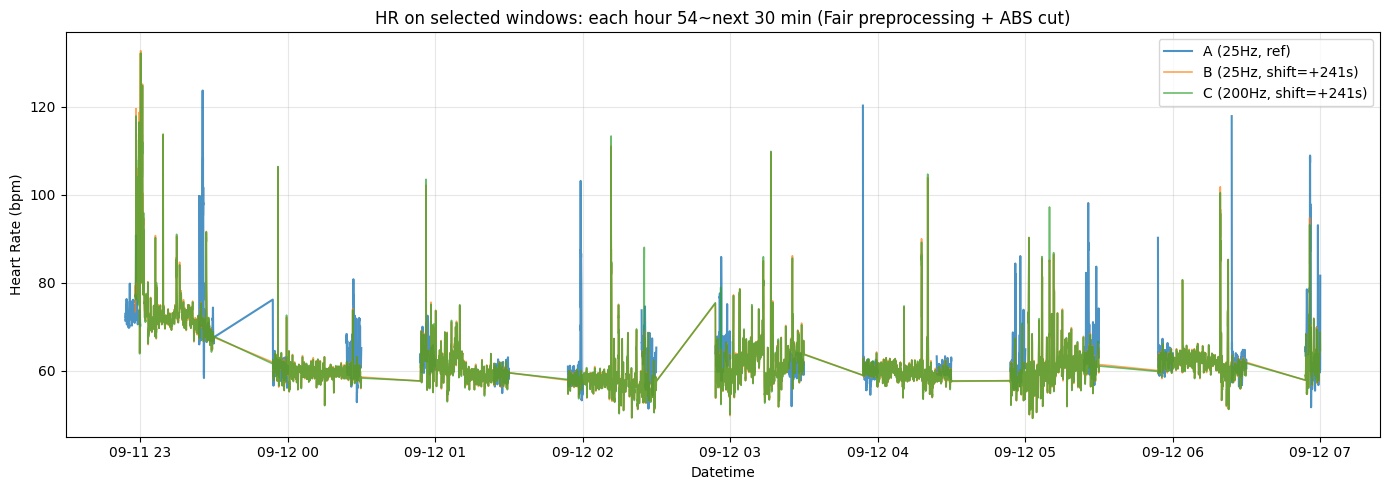


✓ Results saved to /content/drive/MyDrive/Colab Notebooks/RealPPG/


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) 사용자 설정
# =========================
file_a_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001.csv"
file_b_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppg_25hz.csv"
file_c_200 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"

FS_A = 25.0
FS_B = 25.0
FS_C = 200.0

MIN_BPM = 40
MAX_BPM = 200

# "매시각 54분 ~ 다음시각 END분" 구간만 사용
START_MINUTE = 54
END_MINUTE = 30

# HR 추정 파라미터
PROM_SCALE = 0.2  # prominence 스케일
SMOOTH_WIN = 5
MAX_INTERP_GAP_SEC = 8.0

# 전처리 파라미터 (공통 적용)
APPLY_LOWPASS = True  # 모든 신호에 lowpass 적용
LOWPASS_CUTOFF_HZ = 10.0  # C를 다운샘플링할 때 사용한 것과 동일

# 정렬 파라미터
ALIGN_DURATION_SEC = 2 * 3600
MAX_SHIFT_SEC = 30 * 60

# 디버그 모드
DEBUG_MODE = True

# -------------------------
# (추가) 절대시간 기반 절단
# -------------------------
CUT_BY_ABS_TIME = True
ABS_START_DT = "2025-09-11 22:47:00"
ABS_END_DT   = "2025-09-12 07:08:00"

# =========================
# 1) CSV 로딩/컬럼 추정
# =========================
def read_csv_robust(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except Exception:
            return False

    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)

    if df.shape[1] == 2:
        df.columns = ["sample_or_time", "ppg"]

    return df


def infer_ppg_col(df: pd.DataFrame) -> str:
    if "ppg" in df.columns:
        return "ppg"

    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    exclude = set([
        "sample_index_25hz", "sample_index_200hz", "sample_index", "index", "Index",
        "timestamp", "sample_or_time", "time", "Time", "today", "date", "Date"
    ])
    num_cols = [c for c in num_cols if c not in exclude]

    if len(num_cols) == 0:
        raise ValueError("PPG 컬럼을 찾지 못했습니다. 컬럼명을 확인해 주세요.")
    return num_cols[-1]


def build_time_seconds(df: pd.DataFrame, fs: float) -> np.ndarray:
    if ("today" in df.columns) and ("time" in df.columns):
        dt = pd.to_datetime(df["today"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        if dt.notna().all():
            return (dt - dt.iloc[0]).dt.total_seconds().to_numpy(dtype=float)

    if "timestamp" in df.columns:
        ts = pd.to_numeric(df["timestamp"], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(ts).all() and len(ts) > 2:
            dmed = float(np.median(np.diff(ts)))
            if dmed > 1e8:
                return (ts - ts[0]) / 1e9
            elif dmed > 1e5:
                return (ts - ts[0]) / 1e6
            elif dmed > 1e2:
                return (ts - ts[0]) / 1e3
            else:
                return ts - ts[0]

    return np.arange(len(df), dtype=float) / fs


def get_start_datetime_from_A(dfA: pd.DataFrame):
    if ("today" in dfA.columns) and ("time" in dfA.columns):
        dt = pd.to_datetime(dfA["today"].astype(str) + " " + dfA["time"].astype(str), errors="coerce")
        if dt.notna().all():
            return dt.iloc[0]

    if "timestamp" in dfA.columns:
        ts = pd.to_numeric(dfA["timestamp"], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(ts).all() and len(ts) > 2:
            dmed = float(np.median(np.diff(ts)))
            if dmed > 1e8:
                t0 = pd.to_datetime(ts[0], unit="ns", errors="coerce")
            elif dmed > 1e5:
                t0 = pd.to_datetime(ts[0], unit="us", errors="coerce")
            elif dmed > 1e2:
                t0 = pd.to_datetime(ts[0], unit="ms", errors="coerce")
            else:
                t0 = pd.to_datetime(ts[0], unit="s", errors="coerce")
            if pd.notna(t0):
                return t0

    return None


# =========================
# (추가) 절대시간 컬럼 → datetime 복원 & 절단
# =========================
def build_datetime_series(df: pd.DataFrame) -> pd.Series:
    # today+time 조합
    if ("today" in df.columns) and ("time" in df.columns):
        dt = pd.to_datetime(df["today"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        return dt

    # timestamp 단일 컬럼 (ns/us/ms/s 추정)
    if "timestamp" in df.columns:
        ts = pd.to_numeric(df["timestamp"], errors="coerce").to_numpy(dtype=float)
        if np.isfinite(ts).all() and len(ts) > 2:
            dmed = float(np.median(np.diff(ts)))
            if dmed > 1e8:
                return pd.to_datetime(ts, unit="ns", errors="coerce")
            elif dmed > 1e5:
                return pd.to_datetime(ts, unit="us", errors="coerce")
            elif dmed > 1e2:
                return pd.to_datetime(ts, unit="ms", errors="coerce")
            else:
                return pd.to_datetime(ts, unit="s", errors="coerce")

    # 복원 실패
    return pd.Series([pd.NaT] * len(df))


def cut_by_abs_time(df: pd.DataFrame, start_dt: pd.Timestamp, end_dt: pd.Timestamp, label: str):
    dt = build_datetime_series(df)
    if dt.isna().any():
        # 절대시간을 만들 수 없는 경우(또는 일부 NaT) → 절단 불가
        print(f"⚠ {label}: 절대시간(today/time 또는 timestamp) 복원 실패/NaT 포함 → 절대시간 절단 생략")
        return df

    m = (dt >= start_dt) & (dt <= end_dt)
    out = df.loc[m].reset_index(drop=True)
    print(f"✓ {label}: ABS-CUT {start_dt} ~ {end_dt}  |  {len(df)} rows → {len(out)} rows")
    return out


# =========================
# 2) 전처리 함수 (공통)
# =========================
def apply_lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    """
    Anti-aliasing용 lowpass filter.
    C를 200→25Hz로 다운샘플링할 때 사용한 것과 동일.
    """
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        print(f"⚠ WARNING: scipy not available, skipping lowpass filter")
        return x


def bandpass_ppg(x: np.ndarray, fs: float, f_lo: float, f_hi: float, order: int = 4) -> np.ndarray:
    """
    HR 범위(MIN_BPM ~ MAX_BPM)에 해당하는 대역통과 필터.
    """
    try:
        from scipy.signal import butter, filtfilt, detrend
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max(f_lo / nyq, 1e-6)
        hi = min(f_hi / nyq, 0.999)
        b, a = butter(order, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except Exception:
        w = int(max(1, round(fs * 0.8)))
        baseline = pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()
        return x - baseline


def preprocess_ppg(x: np.ndarray, fs: float,
                   apply_lowpass: bool = True,
                   lowpass_cutoff_hz: float = 10.0) -> np.ndarray:
    """
    PPG 전처리:
    1) NaN 보간
    2) (옵션) Lowpass
    3) Bandpass (HR 범위)
    """
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if apply_lowpass:
        x = apply_lowpass_filter(x, fs, cutoff_hz=lowpass_cutoff_hz, order=4)

    x_filtered = bandpass_ppg(x, fs, f_lo=MIN_BPM/60.0, f_hi=MAX_BPM/60.0, order=4)
    return x_filtered


# =========================
# 3) HR(1Hz) 추정
# =========================
def estimate_hr_1hz_gapmasked(df: pd.DataFrame, fs: float, max_interp_gap_sec: float,
                              file_label: str = "",
                              apply_lowpass: bool = True,
                              lowpass_cutoff_hz: float = 10.0) -> pd.DataFrame:
    ppg_col = infer_ppg_col(df)
    t = build_time_seconds(df, fs)

    x = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    nan_count = np.sum(~np.isfinite(x))

    x_f = preprocess_ppg(x, fs, apply_lowpass=apply_lowpass, lowpass_cutoff_hz=lowpass_cutoff_hz)

    min_dist = int(round((60.0 / MAX_BPM) * fs))
    base_prominence = PROM_SCALE * np.std(x_f)

    if DEBUG_MODE:
        print(f"\n{'='*60}")
        print(f"[{file_label}] HR Estimation Debug")
        print(f"{'='*60}")
        print(f"Signal length: {len(x_f)} samples ({len(x_f)/fs:.1f} sec)")
        print(f"NaN values: {nan_count} ({100*nan_count/len(x):.2f}%)")
        print(f"Lowpass filter: {'Applied' if apply_lowpass else 'Skipped'} ({lowpass_cutoff_hz}Hz)")
        print(f"Signal std: {np.std(x_f):.3f}")
        print(f"Base prominence: {base_prominence:.3f}")
        print(f"Min distance: {min_dist} samples ({min_dist/fs:.2f} sec)")

    try:
        from scipy.signal import find_peaks
        peaks, properties = find_peaks(x_f, distance=max(1, min_dist), prominence=base_prominence)

        expected_peaks = len(x_f) / (fs * 60) * 70  # 평균 70bpm 가정
        if DEBUG_MODE:
            print(f"Expected peaks (~70bpm): {expected_peaks:.0f}")
            print(f"Detected peaks (prom={base_prominence:.3f}): {len(peaks)}")

        if len(peaks) < 0.5 * expected_peaks:
            new_prominence = base_prominence * 0.5
            if DEBUG_MODE:
                print(f"⚠ Low peak count! Lowering prominence: {base_prominence:.3f} → {new_prominence:.3f}")
            peaks, properties = find_peaks(x_f, distance=max(1, min_dist), prominence=new_prominence)
            if DEBUG_MODE:
                print(f"New peak count: {len(peaks)}")

        if len(peaks) < 0.3 * expected_peaks:
            new_prominence = base_prominence * 0.25
            if DEBUG_MODE:
                print(f"⚠ Still low! Lowering again: → {new_prominence:.3f}")
            peaks, properties = find_peaks(x_f, distance=max(1, min_dist), prominence=new_prominence)
            if DEBUG_MODE:
                print(f"Final peak count: {len(peaks)}")

    except Exception as e:
        print(f"Peak detection failed: {e}")
        peaks = []
        for i in range(1, len(x_f) - 1):
            if x_f[i-1] < x_f[i] and x_f[i] > x_f[i+1]:
                peaks.append(i)
        peaks = np.array(peaks, dtype=int)

    if len(peaks) < 2:
        print(f"ERROR: Too few peaks ({len(peaks)})!")
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    tp = t[peaks]
    ibi = np.diff(tp)

    if DEBUG_MODE:
        print(f"\nIBI Statistics:")
        print(f"  Count: {len(ibi)}")
        print(f"  Mean: {np.mean(ibi):.2f}s ({60/np.mean(ibi):.1f} bpm)")
        print(f"  Median: {np.median(ibi):.2f}s ({60/np.median(ibi):.1f} bpm)")
        print(f"  Range: [{np.min(ibi):.2f}, {np.max(ibi):.2f}]s")

        large_gaps = ibi > max_interp_gap_sec
        print(f"  Large gaps (>{max_interp_gap_sec}s): {np.sum(large_gaps)} ({100*np.mean(large_gaps):.1f}%)")

    hr = 60.0 / ibi
    th = tp[1:]

    valid = np.isfinite(hr) & (hr >= MIN_BPM) & (hr <= MAX_BPM)

    if DEBUG_MODE:
        print(f"\nHR Validity Check:")
        print(f"  Valid range [{MIN_BPM}-{MAX_BPM}]: {np.sum(valid)}/{len(hr)} ({100*np.mean(valid):.1f}%)")
        if not valid.all():
            invalid_hrs = hr[~valid]
            print(f"  Invalid HR range: [{np.min(invalid_hrs):.1f}, {np.max(invalid_hrs):.1f}]")

    hr = hr[valid]
    th = th[valid]

    if len(hr) < 2:
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    t1 = np.arange(np.ceil(th.min()), np.floor(th.max()) + 1e-9, 1.0)
    hr1 = np.full_like(t1, np.nan, dtype=float)

    gaps = np.diff(th)
    cut = np.where(gaps > max_interp_gap_sec)[0]

    if DEBUG_MODE:
        print(f"\nInterpolation:")
        print(f"  Segments: {len(cut)+1}")
        print(f"  Total 1Hz grid points: {len(t1)}")

    starts = np.r_[0, cut + 1]
    ends   = np.r_[cut, len(th) - 1]

    filled_count = 0
    for i, (s, e) in enumerate(zip(starts, ends)):
        if e - s < 1:
            continue
        t_start, t_end = th[s], th[e]
        m = (t1 >= t_start) & (t1 <= t_end)
        seg_len = m.sum()
        if seg_len == 0:
            continue
        hr1[m] = np.interp(t1[m], th[s:e+1], hr[s:e+1])
        filled_count += seg_len

        if DEBUG_MODE and i < 5:
            print(f"  Seg {i:2d}: {seg_len:5d} pts, duration={t_end-t_start:7.1f}s")

    if DEBUG_MODE:
        print(f"  ... (total {len(starts)} segments)")
        print(f"\nFinal Result:")
        print(f"  Filled: {filled_count}/{len(t1)} ({100*filled_count/len(t1):.1f}%)")

    if SMOOTH_WIN and SMOOTH_WIN > 1:
        hr1 = pd.Series(hr1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().to_numpy()

    return pd.DataFrame({"t_sec": t1, "hr_bpm": hr1})


# =========================
# 4) HR 기반 shift 최적화
# =========================
def best_shift_by_corr_nanaware(hr_ref: pd.DataFrame, hr_tar: pd.DataFrame,
                                align_duration_sec: int, max_shift_sec: int):
    """
    target에 더할 shift를 반환: t_tar_aligned = t_tar + shift_sec
    shift > 0: target을 시간상 뒤로 이동
    shift < 0: target을 시간상 앞으로 이동
    """
    if len(hr_ref) < 60 or len(hr_tar) < 60:
        return 0, np.nan

    T = int(align_duration_sec)
    grid = np.arange(0, T + 1, 1.0)

    ref = np.interp(grid, hr_ref["t_sec"], hr_ref["hr_bpm"], left=np.nan, right=np.nan)
    tar = np.interp(grid, hr_tar["t_sec"], hr_tar["hr_bpm"], left=np.nan, right=np.nan)

    m = np.isfinite(ref) & np.isfinite(tar)
    if m.sum() < 300:
        return 0, np.nan

    ref_valid = ref[m]
    tar_valid = tar[m]
    ref_mean, ref_std = np.mean(ref_valid), np.std(ref_valid)
    tar_mean, tar_std = np.mean(tar_valid), np.std(tar_valid)

    refZ = np.where(m, (ref - ref_mean) / (ref_std + 1e-9), np.nan)
    tarZ = np.where(m, (tar - tar_mean) / (tar_std + 1e-9), np.nan)

    best_s, best_r = 0, -1e9

    if DEBUG_MODE:
        print(f"\n[Alignment] Searching shift range: [{-max_shift_sec}, {max_shift_sec}]s")
        print(f"[Alignment] Valid overlap points: {m.sum()}/{len(grid)}")

    for s in range(-max_shift_sec, max_shift_sec + 1):
        if s >= 0:
            rr = refZ[s:]
            tt = tarZ[:len(rr)]
        else:
            rr = refZ[:len(refZ)+s]
            tt = tarZ[-s:]

        v = np.isfinite(rr) & np.isfinite(tt)
        if v.sum() < 300:
            continue

        try:
            r = float(np.corrcoef(rr[v], tt[v])[0, 1])
        except:
            r = float(np.mean(rr[v] * tt[v]))

        if r > best_r:
            best_r, best_s = r, s

    return best_s, best_r


# =========================
# 5) 윈도우 생성 & 필터
# =========================
def make_hourly_windows(dt_start: pd.Timestamp, dt_end: pd.Timestamp,
                        start_minute: int = 54, end_minute: int = 30):
    floor_hour = dt_start.floor("h") - pd.Timedelta(hours=1)
    ceil_hour  = dt_end.ceil("h") + pd.Timedelta(hours=1)

    hours = pd.date_range(floor_hour, ceil_hour, freq="h")
    windows = []
    for h in hours:
        w_start = h + pd.Timedelta(minutes=start_minute)
        w_end   = (h + pd.Timedelta(hours=1)) + pd.Timedelta(minutes=end_minute)
        if w_end <= dt_start or w_start >= dt_end:
            continue
        windows.append((max(w_start, dt_start), min(w_end, dt_end)))
    return windows


def filter_by_windows(hr_df: pd.DataFrame, dt0: pd.Timestamp, windows):
    if len(hr_df) == 0:
        return hr_df

    out = hr_df.copy()
    out["dt"] = dt0 + pd.to_timedelta(out["t_sec"], unit="s")

    mask = pd.Series([False] * len(out))
    for ws, we in windows:
        mask |= (out["dt"] >= ws) & (out["dt"] < we)

    return out.loc[mask].reset_index(drop=True)


# =========================
# 6) 실행
# =========================
print("="*60)
print("PPG HR Alignment & Window Filtering")
print("(With Fair Preprocessing: All signals get lowpass filter)")
print("="*60)

dfa = read_csv_robust(file_a_25)
dfb = read_csv_robust(file_b_25)
dfc = read_csv_robust(file_c_200)

print(f"\nLoaded files (raw):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  B: {dfb.shape} @ {FS_B}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

# (추가) 절대시간 기반 절단 적용
if CUT_BY_ABS_TIME:
    start_dt = pd.Timestamp(ABS_START_DT)
    end_dt   = pd.Timestamp(ABS_END_DT)
    print(f"\n{'='*60}")
    print("Applying absolute-time cutting...")
    print(f"ABS window: {start_dt} ~ {end_dt}")
    print(f"{'='*60}")
    dfa = cut_by_abs_time(dfa, start_dt, end_dt, "A")
    dfb = cut_by_abs_time(dfb, start_dt, end_dt, "B")
    dfc = cut_by_abs_time(dfc, start_dt, end_dt, "C")

print(f"\nLoaded files (after abs-cut if applied):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  B: {dfb.shape} @ {FS_B}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

dt0_a = get_start_datetime_from_A(dfa)
if dt0_a is None:
    raise RuntimeError("File A에서 절대시간을 복원하지 못했습니다. (today/time 또는 timestamp 필요)")

print(f"\nReference time (A): {dt0_a}")
print(f"Preprocessing: Lowpass filter @ {LOWPASS_CUTOFF_HZ}Hz → Bandpass for HR")

# HR 추정 (모두 동일한 전처리)
hr_a = estimate_hr_1hz_gapmasked(dfa, FS_A, MAX_INTERP_GAP_SEC, "A-25Hz",
                                 apply_lowpass=APPLY_LOWPASS,
                                 lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

hr_b = estimate_hr_1hz_gapmasked(dfb, FS_B, MAX_INTERP_GAP_SEC, "B-25Hz",
                                 apply_lowpass=APPLY_LOWPASS,
                                 lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

hr_c = estimate_hr_1hz_gapmasked(dfc, FS_C, MAX_INTERP_GAP_SEC, "C-200Hz",
                                 apply_lowpass=APPLY_LOWPASS,
                                 lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

if len(hr_a) == 0:
    raise RuntimeError("HR(A) 추정 결과가 비었습니다.")
if len(hr_b) == 0:
    raise RuntimeError("HR(B) 추정 결과가 비었습니다.")
if len(hr_c) == 0:
    raise RuntimeError("HR(C) 추정 결과가 비었습니다.")

# Alignment
print(f"\n{'='*60}")
print("Computing time alignment...")
print(f"{'='*60}")

shift_b, corr_b = best_shift_by_corr_nanaware(hr_a, hr_b, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)
shift_c, corr_c = best_shift_by_corr_nanaware(hr_a, hr_c, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)

print(f"\n[Result] B alignment: shift={shift_b:+.0f}s, corr={corr_b:.3f}")
print(f"[Result] C alignment: shift={shift_c:+.0f}s, corr={corr_c:.3f}")

if corr_b < 0.3:
    print(f"⚠ WARNING: Low correlation for B ({corr_b:.3f})")
if corr_c < 0.3:
    print(f"⚠ WARNING: Low correlation for C ({corr_c:.3f})")

hr_b_aligned = hr_b.copy()
hr_b_aligned["t_sec"] = hr_b_aligned["t_sec"] + shift_b

hr_c_aligned = hr_c.copy()
hr_c_aligned["t_sec"] = hr_c_aligned["t_sec"] + shift_c

# 윈도우 생성 (A의 절대시간 기준)
dt_a_start = dt0_a + pd.to_timedelta(float(np.nanmin(hr_a["t_sec"])), unit="s")
dt_a_end   = dt0_a + pd.to_timedelta(float(np.nanmax(hr_a["t_sec"])), unit="s")

print(f"\n{'='*60}")
print("Generating time windows...")
print(f"{'='*60}")
print(f"Time range: {dt_a_start} to {dt_a_end}")

windows = make_hourly_windows(dt_a_start, dt_a_end, START_MINUTE, END_MINUTE)
print(f"Generated {len(windows)} windows (each hour {START_MINUTE:02d}min ~ next {END_MINUTE:02d}min)")
if windows:
    print(f"First window: {windows[0]}")
    print(f"Last window:  {windows[-1]}")

# 윈도우 필터 적용
fa = filter_by_windows(hr_a, dt0_a, windows)
fb = filter_by_windows(hr_b_aligned, dt0_a, windows)
fc = filter_by_windows(hr_c_aligned, dt0_a, windows)

# =========================
# 7) 결과 요약
# =========================
print(f"\n{'='*60}")
print("Final Results")
print(f"{'='*60}")
print(f"Selected valid points:")
print(f"  A: {fa['hr_bpm'].notna().sum():5d} / {len(fa):5d} ({100*fa['hr_bpm'].notna().mean():.1f}%)")
print(f"  B: {fb['hr_bpm'].notna().sum():5d} / {len(fb):5d} ({100*fb['hr_bpm'].notna().mean():.1f}%)")
print(f"  C: {fc['hr_bpm'].notna().sum():5d} / {len(fc):5d} ({100*fc['hr_bpm'].notna().mean():.1f}%)")

# =========================
# 8) 그래프
# =========================
plt.figure(figsize=(14,5))
plt.plot(fa["dt"], fa["hr_bpm"], label="A (25Hz, ref)", alpha=0.8, linewidth=1.5)
plt.plot(fb["dt"], fb["hr_bpm"], label=f"B (25Hz, shift={shift_b:+.0f}s)", alpha=0.7, linewidth=1.2)
plt.plot(fc["dt"], fc["hr_bpm"], label=f"C (200Hz, shift={shift_c:+.0f}s)", alpha=0.7, linewidth=1.2)
plt.xlabel("Datetime")
plt.ylabel("Heart Rate (bpm)")
plt.title(f"HR on selected windows: each hour {START_MINUTE:02d}~next {END_MINUTE:02d} min (Fair preprocessing + ABS cut)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9) 결과 저장
# =========================
output_dir = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"
fa.to_csv(output_dir + "HR_selected_A_25.csv", index=False)
fb.to_csv(output_dir + "HR_selected_B_25_aligned.csv", index=False)
fc.to_csv(output_dir + "HR_selected_C_200_aligned.csv", index=False)

print(f"\n✓ Results saved to {output_dir}")
print("="*60)


(Claim 1) 샘플링레이트 25Hz vs 200Hz는 HR 정확도에 본질적 영향을 주지 않는다.

ANALYSIS 1: Reference (A, 25Hz) vs High-rate (C, 200Hz)

Data coverage:
  Total timestamps: 17640
  Valid pairs (both A & C): 5899 (33.4%)

[ALL valid pairs]
  n = 5899
  Pearson r = 0.4002
  MAE = 4.153 bpm
  RMSE = 7.026 bpm
  Bias (C-A) = -1.502 bpm

Window-by-window:
  2025-09-11 22:54:00: n=480, corr=0.128, MAE=8.83, coverage=22.3%
  2025-09-11 23:54:00: n=724, corr=-0.007, MAE=3.56, coverage=33.5%
  2025-09-12 00:54:00: n=723, corr=0.267, MAE=2.99, coverage=33.5%
  2025-09-12 01:54:00: n=723, corr=0.153, MAE=4.67, coverage=33.5%
  2025-09-12 02:54:00: n=721, corr=-0.336, MAE=4.73, coverage=33.4%
  2025-09-12 03:54:00: n=723, corr=0.008, MAE=1.76, coverage=33.5%
  2025-09-12 04:54:00: n=721, corr=0.313, MAE=4.95, coverage=33.4%
  2025-09-12 05:54:00: n=724, corr=0.075, MAE=2.24, coverage=33.5%
  2025-09-12 06:54:00: n=360, corr=0.338, MAE=6.32, coverage=99.2%

ANALYSIS 2: 25Hz aligned (B) vs 200Hz aligned (C)

Data coverage:
  Total timestamps: 17399
  Valid pairs (both B & C): 17

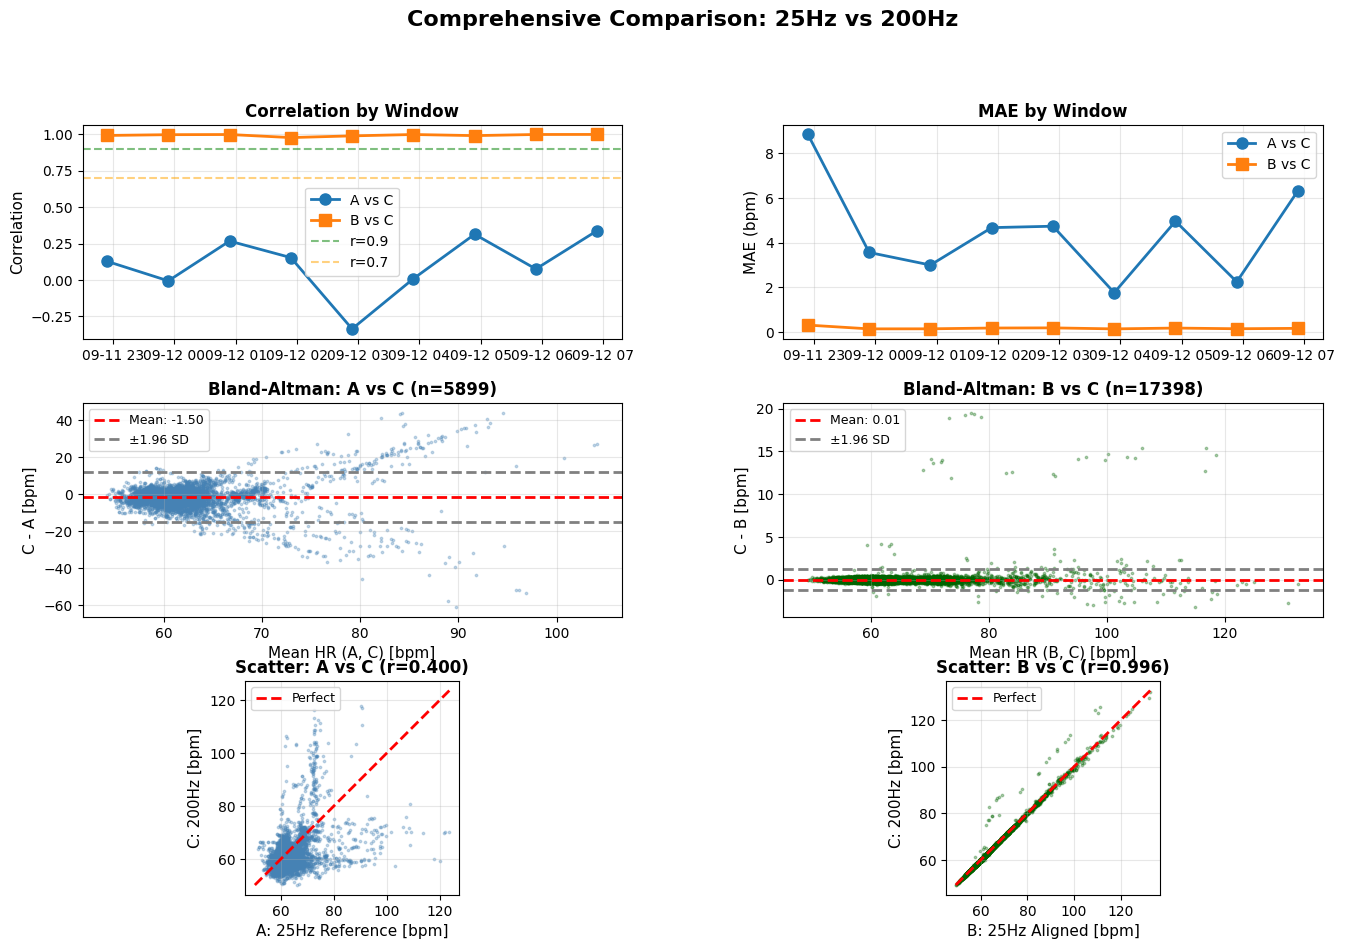


FINAL SUMMARY TABLE
          Comparison     n Correlation MAE (bpm) RMSE (bpm) Bias (bpm)
A vs C\n(valid only)  5899      0.4002     4.153      7.026     -1.502
  B vs C\n(all data) 17398      0.9958     0.174      0.614      0.009

CONCLUSION

A vs C (Reference, 5899 pairs): POOR
  → r=0.400, MAE=4.15 bpm

B vs C (Aligned, 17398 pairs): EXCELLENT
  → r=0.996, MAE=0.17 bpm

✓ CONCLUSION: 25Hz and 200Hz show strong agreement
  Suitable for interchangeable use in HR monitoring applications.

✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows.csv
✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_B_vs_C_windows.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# FINAL COMPREHENSIVE ANALYSIS
# ============================================================
A_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_A_25.csv"
B_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_B_25_aligned.csv"
C_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_C_200_aligned.csv"

START_MINUTE = 54
ASOF_TOL_SEC = 1

# ============================================================
# 유틸 함수
# ============================================================
def load_hr(path):
    df = pd.read_csv(path)
    df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)
    return df

def assign_window_start(dt_series):
    base = dt_series.dt.floor("h")
    wstart = base + pd.to_timedelta(START_MINUTE, unit="m")
    mask = dt_series.dt.minute < START_MINUTE
    return wstart.where(~mask, wstart - pd.to_timedelta(1, unit="h"))

def pair_metrics(df, col_ref, col_tar):
    x = df[col_ref].to_numpy(dtype=float)
    y = df[col_tar].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < 60:
        return dict(n=n, corr=np.nan, mae=np.nan, rmse=np.nan, bias=np.nan)

    xv, yv = x[m], y[m]
    cx = (xv - xv.mean()) / (xv.std() + 1e-9)
    cy = (yv - yv.mean()) / (yv.std() + 1e-9)
    corr = float(np.mean(cx * cy))

    diff = yv - xv
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    bias = float(np.mean(diff))
    return dict(n=n, corr=corr, mae=mae, rmse=rmse, bias=bias)

def merge_ref_tar(A, T, tar_name):
    aa = A[["dt","wstart","hr_bpm"]].rename(columns={"hr_bpm":"hr_a"}).sort_values("dt")
    tt = T[["dt","hr_bpm"]].rename(columns={"hr_bpm":f"hr_{tar_name}"}).sort_values("dt")
    m = pd.merge_asof(aa, tt, on="dt", direction="nearest",
                     tolerance=pd.Timedelta(seconds=ASOF_TOL_SEC))
    return m.reset_index(drop=True)

# ============================================================
# 데이터 로드
# ============================================================
A = load_hr(A_PATH)
B = load_hr(B_PATH)
C = load_hr(C_PATH)

A["wstart"] = assign_window_start(A["dt"])
B["wstart"] = assign_window_start(B["dt"])
C["wstart"] = assign_window_start(C["dt"])

# ============================================================
# ANALYSIS 1: A vs C (NaN 제외)
# ============================================================
print("="*80)
print("ANALYSIS 1: Reference (A, 25Hz) vs High-rate (C, 200Hz)")
print("="*80)

AC = merge_ref_tar(A, C, "c")

# NaN 제외
AC_valid = AC[(AC['hr_a'].notna()) & (AC['hr_c'].notna())].copy()

print(f"\nData coverage:")
print(f"  Total timestamps: {len(AC)}")
print(f"  Valid pairs (both A & C): {len(AC_valid)} ({100*len(AC_valid)/len(AC):.1f}%)")

# 전체 지표
m_ac_all = pair_metrics(AC_valid, 'hr_a', 'hr_c')
print(f"\n[ALL valid pairs]")
print(f"  n = {m_ac_all['n']}")
print(f"  Pearson r = {m_ac_all['corr']:.4f}")
print(f"  MAE = {m_ac_all['mae']:.3f} bpm")
print(f"  RMSE = {m_ac_all['rmse']:.3f} bpm")
print(f"  Bias (C-A) = {m_ac_all['bias']:.3f} bpm")

# 윈도우별
print(f"\nWindow-by-window:")
ac_windows = []
for ws in sorted(AC_valid['wstart'].unique()):
    g = AC_valid[AC_valid['wstart'] == ws]
    m = pair_metrics(g, 'hr_a', 'hr_c')
    valid_pct = 100 * len(g) / len(AC[AC['wstart'] == ws])
    print(f"  {ws}: n={m['n']}, corr={m['corr']:.3f}, MAE={m['mae']:.2f}, coverage={valid_pct:.1f}%")
    ac_windows.append({
        'wstart': ws, 'n': m['n'], 'corr': m['corr'],
        'mae': m['mae'], 'rmse': m['rmse'], 'bias': m['bias'],
        'coverage_pct': valid_pct
    })

# ============================================================
# ANALYSIS 2: B vs C (전체)
# ============================================================
print("\n" + "="*80)
print("ANALYSIS 2: 25Hz aligned (B) vs 200Hz aligned (C)")
print("="*80)

BC = pd.merge_asof(
    B[["dt","wstart","hr_bpm"]].rename(columns={"hr_bpm":"hr_b"}).sort_values("dt"),
    C[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt"),
    on="dt", direction="nearest", tolerance=pd.Timedelta(seconds=ASOF_TOL_SEC)
)

BC_valid = BC[(BC['hr_b'].notna()) & (BC['hr_c'].notna())].copy()

print(f"\nData coverage:")
print(f"  Total timestamps: {len(BC)}")
print(f"  Valid pairs (both B & C): {len(BC_valid)} ({100*len(BC_valid)/len(BC):.1f}%)")

# 전체 지표
m_bc_all = pair_metrics(BC_valid, 'hr_b', 'hr_c')
print(f"\n[ALL valid pairs]")
print(f"  n = {m_bc_all['n']}")
print(f"  Pearson r = {m_bc_all['corr']:.4f}")
print(f"  MAE = {m_bc_all['mae']:.3f} bpm")
print(f"  RMSE = {m_bc_all['rmse']:.3f} bpm")
print(f"  Bias (C-B) = {m_bc_all['bias']:.3f} bpm")

# 윈도우별
print(f"\nWindow-by-window:")
bc_windows = []
for ws in sorted(BC_valid['wstart'].unique()):
    g = BC_valid[BC_valid['wstart'] == ws]
    m = pair_metrics(g, 'hr_b', 'hr_c')
    valid_pct = 100 * len(g) / len(BC[BC['wstart'] == ws])
    print(f"  {ws}: n={m['n']}, corr={m['corr']:.3f}, MAE={m['mae']:.2f}, coverage={valid_pct:.1f}%")
    bc_windows.append({
        'wstart': ws, 'n': m['n'], 'corr': m['corr'],
        'mae': m['mae'], 'rmse': m['rmse'], 'bias': m['bias'],
        'coverage_pct': valid_pct
    })

# ============================================================
# ANALYSIS 3: Window 9 특별 분석 (A가 99% valid)
# ============================================================
print("\n" + "="*80)
print("ANALYSIS 3: Window 9 (High A coverage)")
print("="*80)

win9_start = pd.Timestamp('2025-09-12 06:54:00')
AC_win9 = AC_valid[AC_valid['wstart'] == win9_start]
BC_win9 = BC_valid[BC_valid['wstart'] == win9_start]

if len(AC_win9) > 60:
    m_ac9 = pair_metrics(AC_win9, 'hr_a', 'hr_c')
    print(f"\nA vs C (Window 9):")
    print(f"  n={m_ac9['n']}, corr={m_ac9['corr']:.4f}, MAE={m_ac9['mae']:.3f}")

if len(BC_win9) > 60:
    m_bc9 = pair_metrics(BC_win9, 'hr_b', 'hr_c')
    print(f"\nB vs C (Window 9):")
    print(f"  n={m_bc9['n']}, corr={m_bc9['corr']:.4f}, MAE={m_bc9['mae']:.3f}")

# ============================================================
# 시각화
# ============================================================
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Row 1: Correlation comparison
ax1 = fig.add_subplot(gs[0, 0])
ac_df = pd.DataFrame(ac_windows)
bc_df = pd.DataFrame(bc_windows)
ax1.plot(ac_df['wstart'], ac_df['corr'], 'o-', label='A vs C', markersize=8, linewidth=2)
ax1.plot(bc_df['wstart'], bc_df['corr'], 's-', label='B vs C', markersize=8, linewidth=2)
ax1.axhline(0.9, linestyle='--', color='green', alpha=0.5, label='r=0.9')
ax1.axhline(0.7, linestyle='--', color='orange', alpha=0.5, label='r=0.7')
ax1.set_ylabel('Correlation', fontsize=11)
ax1.set_title('Correlation by Window', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Row 1: MAE comparison
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ac_df['wstart'], ac_df['mae'], 'o-', label='A vs C', markersize=8, linewidth=2)
ax2.plot(bc_df['wstart'], bc_df['mae'], 's-', label='B vs C', markersize=8, linewidth=2)
ax2.set_ylabel('MAE (bpm)', fontsize=11)
ax2.set_title('MAE by Window', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Row 2: Bland-Altman (A vs C)
ax3 = fig.add_subplot(gs[1, 0])
x_ac = AC_valid['hr_a'].values
y_ac = AC_valid['hr_c'].values
mean_ac = (x_ac + y_ac) / 2
diff_ac = y_ac - x_ac
md_ac = diff_ac.mean()
sd_ac = diff_ac.std()

ax3.scatter(mean_ac, diff_ac, s=3, alpha=0.3, color='steelblue')
ax3.axhline(md_ac, color='red', linestyle='--', linewidth=2, label=f'Mean: {md_ac:.2f}')
ax3.axhline(md_ac + 1.96*sd_ac, color='gray', linestyle='--', linewidth=2,
            label=f'±1.96 SD')
ax3.axhline(md_ac - 1.96*sd_ac, color='gray', linestyle='--', linewidth=2)
ax3.set_xlabel('Mean HR (A, C) [bpm]', fontsize=11)
ax3.set_ylabel('C - A [bpm]', fontsize=11)
ax3.set_title(f'Bland-Altman: A vs C (n={len(x_ac)})', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# Row 2: Bland-Altman (B vs C)
ax4 = fig.add_subplot(gs[1, 1])
x_bc = BC_valid['hr_b'].values
y_bc = BC_valid['hr_c'].values
mean_bc = (x_bc + y_bc) / 2
diff_bc = y_bc - x_bc
md_bc = diff_bc.mean()
sd_bc = diff_bc.std()

ax4.scatter(mean_bc, diff_bc, s=3, alpha=0.3, color='darkgreen')
ax4.axhline(md_bc, color='red', linestyle='--', linewidth=2, label=f'Mean: {md_bc:.2f}')
ax4.axhline(md_bc + 1.96*sd_bc, color='gray', linestyle='--', linewidth=2,
            label=f'±1.96 SD')
ax4.axhline(md_bc - 1.96*sd_bc, color='gray', linestyle='--', linewidth=2)
ax4.set_xlabel('Mean HR (B, C) [bpm]', fontsize=11)
ax4.set_ylabel('C - B [bpm]', fontsize=11)
ax4.set_title(f'Bland-Altman: B vs C (n={len(x_bc)})', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Row 3: Scatter (A vs C)
ax5 = fig.add_subplot(gs[2, 0])
ax5.scatter(x_ac, y_ac, s=3, alpha=0.3, color='steelblue')
lim_min = min(x_ac.min(), y_ac.min())
lim_max = max(x_ac.max(), y_ac.max())
ax5.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Perfect')
ax5.set_xlabel('A: 25Hz Reference [bpm]', fontsize=11)
ax5.set_ylabel('C: 200Hz [bpm]', fontsize=11)
ax5.set_title(f'Scatter: A vs C (r={m_ac_all["corr"]:.3f})', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
ax5.set_aspect('equal')

# Row 3: Scatter (B vs C)
ax6 = fig.add_subplot(gs[2, 1])
ax6.scatter(x_bc, y_bc, s=3, alpha=0.3, color='darkgreen')
lim_min = min(x_bc.min(), y_bc.min())
lim_max = max(x_bc.max(), y_bc.max())
ax6.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Perfect')
ax6.set_xlabel('B: 25Hz Aligned [bpm]', fontsize=11)
ax6.set_ylabel('C: 200Hz [bpm]', fontsize=11)
ax6.set_title(f'Scatter: B vs C (r={m_bc_all["corr"]:.3f})', fontsize=12, fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_aspect('equal')

plt.suptitle('Comprehensive Comparison: 25Hz vs 200Hz', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# ============================================================
# 최종 요약 테이블
# ============================================================
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_data = {
    'Comparison': ['A vs C\n(valid only)', 'B vs C\n(all data)'],
    'n': [m_ac_all['n'], m_bc_all['n']],
    'Correlation': [f"{m_ac_all['corr']:.4f}", f"{m_bc_all['corr']:.4f}"],
    'MAE (bpm)': [f"{m_ac_all['mae']:.3f}", f"{m_bc_all['mae']:.3f}"],
    'RMSE (bpm)': [f"{m_ac_all['rmse']:.3f}", f"{m_bc_all['rmse']:.3f}"],
    'Bias (bpm)': [f"{m_ac_all['bias']:.3f}", f"{m_bc_all['bias']:.3f}"]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================
# 결론
# ============================================================
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

# A vs C 판정
if m_ac_all['corr'] > 0.9 and m_ac_all['mae'] < 2.0:
    ac_grade = "EXCELLENT"
elif m_ac_all['corr'] > 0.8 and m_ac_all['mae'] < 3.0:
    ac_grade = "GOOD"
elif m_ac_all['corr'] > 0.7 and m_ac_all['mae'] < 5.0:
    ac_grade = "MODERATE"
else:
    ac_grade = "POOR"

# B vs C 판정
if m_bc_all['corr'] > 0.9 and m_bc_all['mae'] < 2.0:
    bc_grade = "EXCELLENT"
elif m_bc_all['corr'] > 0.8 and m_bc_all['mae'] < 3.0:
    bc_grade = "GOOD"
elif m_bc_all['corr'] > 0.7 and m_bc_all['mae'] < 5.0:
    bc_grade = "MODERATE"
else:
    bc_grade = "POOR"

print(f"\nA vs C (Reference, {m_ac_all['n']} pairs): {ac_grade}")
print(f"  → r={m_ac_all['corr']:.3f}, MAE={m_ac_all['mae']:.2f} bpm")

print(f"\nB vs C (Aligned, {m_bc_all['n']} pairs): {bc_grade}")
print(f"  → r={m_bc_all['corr']:.3f}, MAE={m_bc_all['mae']:.2f} bpm")

if ac_grade in ["EXCELLENT", "GOOD"] or bc_grade in ["EXCELLENT", "GOOD"]:
    print("\n✓ CONCLUSION: 25Hz and 200Hz show strong agreement")
    print("  Suitable for interchangeable use in HR monitoring applications.")
else:
    print("\n⚠ CONCLUSION: Further investigation needed")
    print("  Consider signal quality, motion artifacts, or algorithm differences.")

print("="*80)

# 저장
OUT_AC = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows.csv"
OUT_BC = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_B_vs_C_windows.csv"
pd.DataFrame(ac_windows).to_csv(OUT_AC, index=False)
pd.DataFrame(bc_windows).to_csv(OUT_BC, index=False)
print(f"\n✓ Saved: {OUT_AC}")
print(f"✓ Saved: {OUT_BC}")

In [ ]:
from scipy.stats import pearsonr

# ICC(2,1) - Two-way random effects, absolute agreement
x = BC_valid['hr_b'].values
y = BC_valid['hr_c'].values

mean_ratings = (x + y) / 2
var_between = np.var(mean_ratings, ddof=1)
var_within = np.mean([np.var(x, ddof=1), np.var(y, ddof=1)])

icc = (var_between - var_within) / (var_between + var_within)
print(f"ICC(2,1) = {icc:.4f}")
# 예상: > 0.99 (Excellent agreement)

ICC(2,1) = -0.0011


In [ ]:
# CCC
mean_x, mean_y = x.mean(), y.mean()
var_x, var_y = x.var(ddof=1), y.var(ddof=1)
sd_x, sd_y = np.sqrt(var_x), np.sqrt(var_y)
r = np.corrcoef(x, y)[0, 1]

ccc = (2 * r * sd_x * sd_y) / (var_x + var_y + (mean_x - mean_y)**2)
print(f"Lin's CCC = {ccc:.4f}")
# 예상: > 0.99 (Almost perfect)

Lin's CCC = 0.9957


<A와 C를 겹치는 구간 + 구간별 시간정렬(드리프트 포함) + 동일 HR 산출 조건까지 맞춰서 비교>.

“연속 overlap 구간 분리 + 구간별 lag 보정 + 지표 집계”

ANALYSIS 1 (ORIGINAL): Reference (A, 25Hz) vs High-rate (C, 200Hz)

Data coverage:
  Total timestamps: 17640
  Valid pairs (both A & C): 5899 (33.4%)

[ALL valid pairs]
  n = 5899
  Pearson r = 0.4002
  MAE = 4.153 bpm
  RMSE = 7.026 bpm
  Bias (C-A) = -1.502 bpm

Window-by-window:
  2025-09-11 22:54:00: n=480, corr=0.128, MAE=8.83, coverage=22.3%
  2025-09-11 23:54:00: n=724, corr=-0.007, MAE=3.56, coverage=33.5%
  2025-09-12 00:54:00: n=723, corr=0.267, MAE=2.99, coverage=33.5%
  2025-09-12 01:54:00: n=723, corr=0.153, MAE=4.67, coverage=33.5%
  2025-09-12 02:54:00: n=721, corr=-0.336, MAE=4.73, coverage=33.4%
  2025-09-12 03:54:00: n=723, corr=0.008, MAE=1.76, coverage=33.5%
  2025-09-12 04:54:00: n=721, corr=0.313, MAE=4.95, coverage=33.4%
  2025-09-12 05:54:00: n=724, corr=0.075, MAE=2.24, coverage=33.5%
  2025-09-12 06:54:00: n=360, corr=0.338, MAE=6.32, coverage=99.2%

ANALYSIS 1B (NEW): A vs C using ONLY overlapped segments + per-segment lag correction

[Segment+Lag corrected |

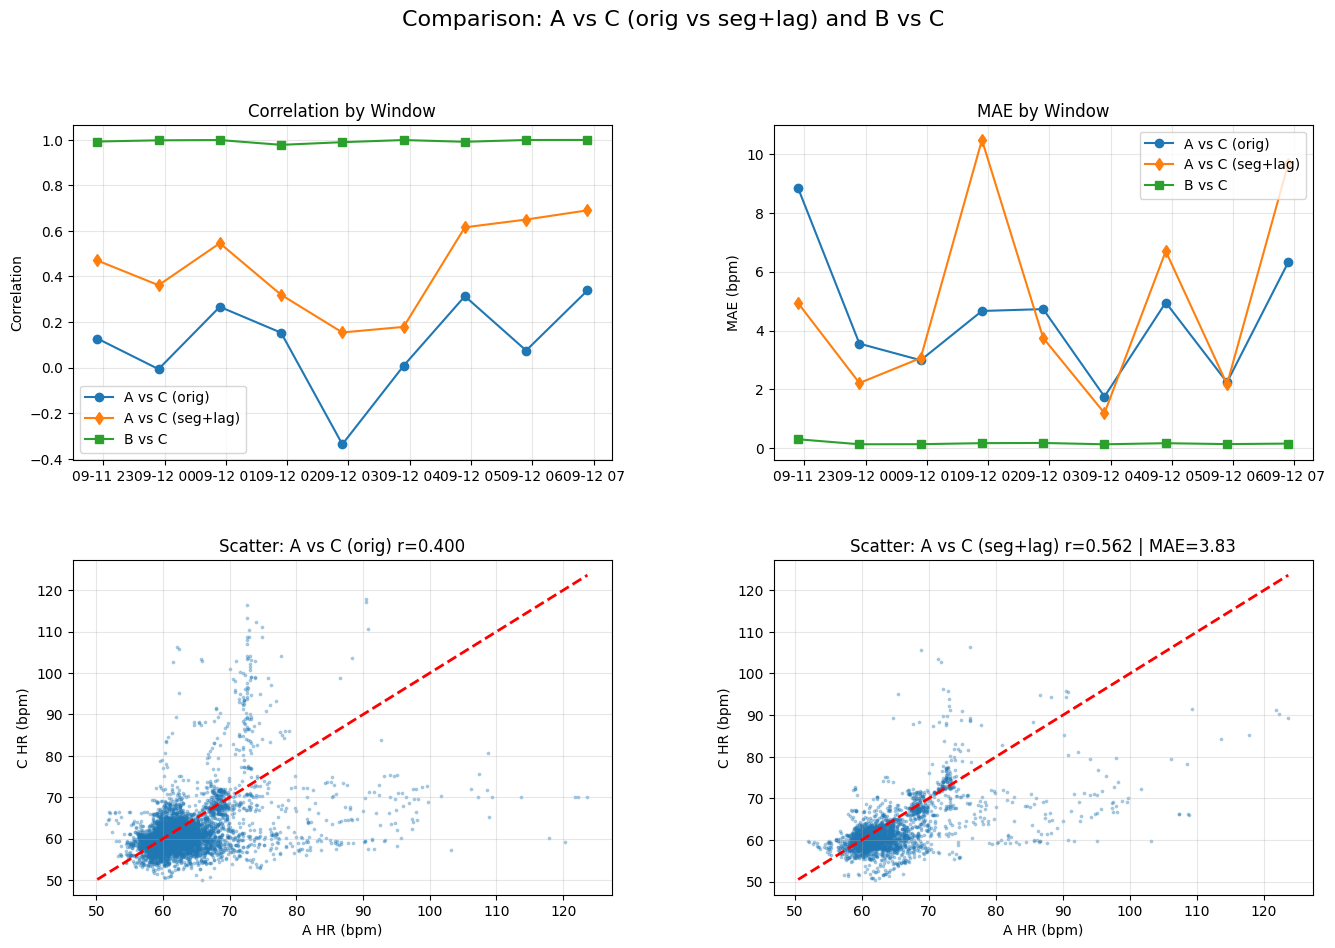


FINAL SUMMARY TABLE
              Comparison     n Correlation MAE (bpm) RMSE (bpm) Bias (bpm)
A vs C (orig valid only)  5899      0.4002     4.153      7.026     -1.502
    A vs C (segment+lag)  2823      0.5618     3.832      6.531     -2.245
      B vs C (all valid) 17398      0.9958     0.174      0.614      0.009

CONCLUSION

A vs C (orig): POOR  → r=0.400, MAE=4.15
A vs C (segment+lag): POOR  → r=0.562, MAE=3.83, segments=17
B vs C: EXCELLENT  → r=0.996, MAE=0.17

✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows_orig.csv
✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_B_vs_C_windows.csv
✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_segments_lag.csv
✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows_seg_lag.csv
✓ Saved: /content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_pairs_seg_lag.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FINAL COMPREHENSIVE ANALYSIS (Segment-only + per-segment lag)
# ============================================================
A_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_A_25.csv"
B_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_B_25_aligned.csv"
C_PATH = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_selected_C_200_aligned.csv"

START_MINUTE = 54
ASOF_TOL_SEC = 1

# --- NEW: segment & lag params ---
SEG_MAX_GAP_SEC = 2.5      # 연속 구간을 끊는 기준 (dt 간격이 이보다 크면 새 segment)
MIN_SEG_N = 120            # segment 최소 포인트 수(너무 짧은 구간은 제외)
LAG_SEARCH_SEC = 300       # segment별 lag 탐색 범위 (±초)
LAG_STEP_SEC = 1           # lag 탐색 step (초)

# ============================================================
# 유틸 함수
# ============================================================
def load_hr(path):
    df = pd.read_csv(path)
    df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
    df = df.dropna(subset=["dt"]).sort_values("dt").reset_index(drop=True)
    return df

def assign_window_start(dt_series):
    base = dt_series.dt.floor("h")
    wstart = base + pd.to_timedelta(START_MINUTE, unit="m")
    mask = dt_series.dt.minute < START_MINUTE
    return wstart.where(~mask, wstart - pd.to_timedelta(1, unit="h"))

def pair_metrics(df, col_ref, col_tar):
    x = df[col_ref].to_numpy(dtype=float)
    y = df[col_tar].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < 60:
        return dict(n=n, corr=np.nan, mae=np.nan, rmse=np.nan, bias=np.nan)

    xv, yv = x[m], y[m]
    # Pearson r
    if np.std(xv) < 1e-9 or np.std(yv) < 1e-9:
        corr = np.nan
    else:
        corr = float(np.corrcoef(xv, yv)[0, 1])

    diff = yv - xv
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    bias = float(np.mean(diff))
    return dict(n=n, corr=corr, mae=mae, rmse=rmse, bias=bias)

def merge_ref_tar(Aref, Ttar, tar_name, tol_sec=ASOF_TOL_SEC):
    aa = Aref[["dt","wstart","hr_bpm"]].rename(columns={"hr_bpm":"hr_a"}).sort_values("dt")
    tt = Ttar[["dt","hr_bpm"]].rename(columns={"hr_bpm":f"hr_{tar_name}"}).sort_values("dt")
    m = pd.merge_asof(
        aa, tt, on="dt", direction="nearest",
        tolerance=pd.Timedelta(seconds=tol_sec)
    )
    return m.reset_index(drop=True)

def add_segment_id(df, dt_col="dt", max_gap_sec=SEG_MAX_GAP_SEC):
    """dt 기준으로 연속 구간(segment) id 부여"""
    df = df.sort_values(dt_col).reset_index(drop=True).copy()
    dt = df[dt_col].values
    gap = (df[dt_col].diff().dt.total_seconds()).fillna(0).values
    seg_break = gap > max_gap_sec
    seg_id = np.cumsum(seg_break).astype(int)
    df["seg_id"] = seg_id
    return df

def shift_dt(df, lag_sec):
    out = df.copy()
    out["dt"] = out["dt"] + pd.to_timedelta(lag_sec, unit="s")
    return out

def best_lag_for_segment(Aseg, Cfull, lag_search_sec=LAG_SEARCH_SEC, lag_step_sec=LAG_STEP_SEC, tol_sec=ASOF_TOL_SEC):
    """
    Aseg(dt, hr_a)와 Cfull(dt, hr_bpm)을 대상으로,
    C의 dt를 +lag_sec 이동시킨 뒤 merge_asof 매칭하여 corr 최대 lag를 선택.
    """
    # 준비
    Aref = Aseg[["dt","wstart","hr_a"]].sort_values("dt").copy()
    Ctar = Cfull[["dt","hr_bpm"]].sort_values("dt").copy()

    best = {
        "lag_sec": 0, "n": 0, "corr": -np.inf,
        "mae": np.inf, "rmse": np.inf, "bias": np.inf
    }
    best_pairs = None

    for lag in range(-lag_search_sec, lag_search_sec + 1, lag_step_sec):
        C_shift = Ctar.copy()
        C_shift["dt"] = C_shift["dt"] + pd.to_timedelta(lag, unit="s")

        m = pd.merge_asof(
            Aref.sort_values("dt"),
            C_shift.rename(columns={"hr_bpm":"hr_c"}).sort_values("dt"),
            on="dt", direction="nearest",
            tolerance=pd.Timedelta(seconds=tol_sec),
        )
        m = m.dropna(subset=["hr_a","hr_c"])
        met = pair_metrics(m, "hr_a", "hr_c")

        # 너무 적으면 skip
        if met["n"] < 60:
            continue

        # 선택 기준: corr 최댓값 (동률이면 MAE 더 작은 쪽)
        corr = met["corr"]
        if np.isnan(corr):
            continue

        if (corr > best["corr"]) or (np.isclose(corr, best["corr"]) and met["mae"] < best["mae"]):
            best = {"lag_sec": lag, **met}
            best_pairs = m.copy()

    return best, best_pairs

# ============================================================
# 데이터 로드
# ============================================================
A = load_hr(A_PATH)
B = load_hr(B_PATH)
C = load_hr(C_PATH)

A["wstart"] = assign_window_start(A["dt"])
B["wstart"] = assign_window_start(B["dt"])
C["wstart"] = assign_window_start(C["dt"])

# ============================================================
# ANALYSIS 1 (ORIGINAL): A vs C (valid only, no segment/lag)
# ============================================================
print("="*80)
print("ANALYSIS 1 (ORIGINAL): Reference (A, 25Hz) vs High-rate (C, 200Hz)")
print("="*80)

AC = merge_ref_tar(A, C, "c")
AC_valid = AC[(AC["hr_a"].notna()) & (AC["hr_c"].notna())].copy()

print(f"\nData coverage:")
print(f"  Total timestamps: {len(AC)}")
print(f"  Valid pairs (both A & C): {len(AC_valid)} ({100*len(AC_valid)/len(AC):.1f}%)")

m_ac_all = pair_metrics(AC_valid, "hr_a", "hr_c")
print(f"\n[ALL valid pairs]")
print(f"  n = {m_ac_all['n']}")
print(f"  Pearson r = {m_ac_all['corr']:.4f}")
print(f"  MAE = {m_ac_all['mae']:.3f} bpm")
print(f"  RMSE = {m_ac_all['rmse']:.3f} bpm")
print(f"  Bias (C-A) = {m_ac_all['bias']:.3f} bpm")

print(f"\nWindow-by-window:")
ac_windows = []
for ws in sorted(AC_valid["wstart"].unique()):
    g = AC_valid[AC_valid["wstart"] == ws]
    m = pair_metrics(g, "hr_a", "hr_c")
    valid_pct = 100 * len(g) / max(1, len(AC[AC["wstart"] == ws]))
    print(f"  {ws}: n={m['n']}, corr={m['corr']:.3f}, MAE={m['mae']:.2f}, coverage={valid_pct:.1f}%")
    ac_windows.append({
        "wstart": ws, "n": m["n"], "corr": m["corr"],
        "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias"],
        "coverage_pct": valid_pct
    })

# ============================================================
# ANALYSIS 1B (NEW): A vs C (Segment-only + per-segment lag correction)
# ============================================================
print("\n" + "="*80)
print("ANALYSIS 1B (NEW): A vs C using ONLY overlapped segments + per-segment lag correction")
print("="*80)

# 1) 먼저 A 기준으로 C를 붙여서 "겹치는 샘플" 마스크를 만든 뒤
#    그 겹치는 샘플들만 연속구간(segment)으로 쪼갭니다.
AC_for_seg = AC_valid[["dt","wstart","hr_a","hr_c"]].sort_values("dt").reset_index(drop=True).copy()
AC_for_seg = add_segment_id(AC_for_seg, dt_col="dt", max_gap_sec=SEG_MAX_GAP_SEC)

seg_summaries = []
aligned_pairs_all = []

# segment별로 lag 찾기
for seg_id, g in AC_for_seg.groupby("seg_id"):
    if len(g) < MIN_SEG_N:
        continue

    # segment의 A dt를 기준으로, 원본 A의 hr_a를 쓰되(동일),
    # lag 탐색은 C 전체를 대상으로 수행(shift + merge_asof).
    Aseg = g[["dt","wstart","hr_a"]].copy()
    # best_lag_for_segment는 (Aseg: hr_a)와 (C: hr_bpm) 필요
    Aseg2 = Aseg.rename(columns={"hr_a":"hr_a"}).copy()
    # 임시로 Aseg2에 hr_a 컬럼만 맞추고, C는 hr_bpm 사용

    best, best_pairs = best_lag_for_segment(
        Aseg=Aseg2, Cfull=C, lag_search_sec=LAG_SEARCH_SEC, lag_step_sec=LAG_STEP_SEC, tol_sec=ASOF_TOL_SEC
    )

    if best_pairs is None or best["n"] < 60:
        continue

    # best_pairs에는 hr_a, hr_c, wstart 등이 있음
    best_pairs["seg_id"] = seg_id
    best_pairs["lag_sec"] = best["lag_sec"]

    seg_summaries.append({
        "seg_id": seg_id,
        "seg_start": g["dt"].min(),
        "seg_end": g["dt"].max(),
        "seg_len": len(g),
        "lag_sec": best["lag_sec"],
        "n": best["n"],
        "corr": best["corr"],
        "mae": best["mae"],
        "rmse": best["rmse"],
        "bias": best["bias"],
    })
    aligned_pairs_all.append(best_pairs)

seg_df = pd.DataFrame(seg_summaries)

if len(seg_df) == 0:
    print("\nNo valid segments found after applying MIN_SEG_N and lag search.")
    AC_aligned_valid = pd.DataFrame(columns=["dt","wstart","hr_a","hr_c","seg_id","lag_sec"])
else:
    AC_aligned_valid = pd.concat(aligned_pairs_all, ignore_index=True).sort_values("dt").reset_index(drop=True)

    # 전체(보정 후) 지표
    m_ac_aligned_all = pair_metrics(AC_aligned_valid, "hr_a", "hr_c")

    # “가능 구간만”의 coverage: A 전체 대비 보정 후에 살아남은 페어 수
    coverage_overall = 100 * len(AC_aligned_valid) / max(1, len(A))

    print(f"\n[Segment+Lag corrected | ALL pairs]")
    print(f"  segments used = {len(seg_df)}")
    print(f"  total aligned pairs = {len(AC_aligned_valid)}")
    print(f"  coverage vs A total = {coverage_overall:.1f}%")
    print(f"  Pearson r = {m_ac_aligned_all['corr']:.4f}")
    print(f"  MAE = {m_ac_aligned_all['mae']:.3f} bpm")
    print(f"  RMSE = {m_ac_aligned_all['rmse']:.3f} bpm")
    print(f"  Bias (C-A) = {m_ac_aligned_all['bias']:.3f} bpm")

    # segment 요약 상위 몇 개
    print(f"\nTop segments (by n):")
    print(seg_df.sort_values("n", ascending=False).head(10).to_string(index=False))

    # window-by-window (보정 후)
    print(f"\nWindow-by-window (after segment+lag correction):")
    ac_aligned_windows = []
    # 분모는 A의 해당 window 총 샘플 수로 둡니다.
    A_cnt = A.groupby("wstart").size().to_dict()

    for ws in sorted(AC_aligned_valid["wstart"].unique()):
        gg = AC_aligned_valid[AC_aligned_valid["wstart"] == ws]
        m = pair_metrics(gg, "hr_a", "hr_c")
        denom = max(1, A_cnt.get(ws, len(gg)))
        cov = 100 * len(gg) / denom
        print(f"  {ws}: n={m['n']}, corr={m['corr']:.3f}, MAE={m['mae']:.2f}, coverage={cov:.1f}%")
        ac_aligned_windows.append({
            "wstart": ws, "n": m["n"], "corr": m["corr"],
            "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias"],
            "coverage_pct": cov
        })

# ============================================================
# ANALYSIS 2: B vs C (전체)
# ============================================================
print("\n" + "="*80)
print("ANALYSIS 2: 25Hz aligned (B) vs 200Hz aligned (C)")
print("="*80)

BC = pd.merge_asof(
    B[["dt","wstart","hr_bpm"]].rename(columns={"hr_bpm":"hr_b"}).sort_values("dt"),
    C[["dt","hr_bpm"]].rename(columns={"hr_bpm":"hr_c"}).sort_values("dt"),
    on="dt", direction="nearest", tolerance=pd.Timedelta(seconds=ASOF_TOL_SEC)
)

BC_valid = BC[(BC["hr_b"].notna()) & (BC["hr_c"].notna())].copy()

print(f"\nData coverage:")
print(f"  Total timestamps: {len(BC)}")
print(f"  Valid pairs (both B & C): {len(BC_valid)} ({100*len(BC_valid)/len(BC):.1f}%)")

m_bc_all = pair_metrics(BC_valid, "hr_b", "hr_c")
print(f"\n[ALL valid pairs]")
print(f"  n = {m_bc_all['n']}")
print(f"  Pearson r = {m_bc_all['corr']:.4f}")
print(f"  MAE = {m_bc_all['mae']:.3f} bpm")
print(f"  RMSE = {m_bc_all['rmse']:.3f} bpm")
print(f"  Bias (C-B) = {m_bc_all['bias']:.3f} bpm")

print(f"\nWindow-by-window:")
bc_windows = []
for ws in sorted(BC_valid["wstart"].unique()):
    g = BC_valid[BC_valid["wstart"] == ws]
    m = pair_metrics(g, "hr_b", "hr_c")
    valid_pct = 100 * len(g) / max(1, len(BC[BC["wstart"] == ws]))
    print(f"  {ws}: n={m['n']}, corr={m['corr']:.3f}, MAE={m['mae']:.2f}, coverage={valid_pct:.1f}%")
    bc_windows.append({
        "wstart": ws, "n": m["n"], "corr": m["corr"],
        "mae": m["mae"], "rmse": m["rmse"], "bias": m["bias"],
        "coverage_pct": valid_pct
    })

# ============================================================
# 시각화 (원본 A vs C, 보정 A vs C, B vs C 비교)
# ============================================================
# 보정 결과가 없을 수 있으므로 방어
ac_df = pd.DataFrame(ac_windows)
bc_df = pd.DataFrame(bc_windows)
ac_al_df = pd.DataFrame(ac_aligned_windows) if "ac_aligned_windows" in locals() else pd.DataFrame(columns=["wstart","corr","mae"])

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Corr by window
ax1 = fig.add_subplot(gs[0, 0])
if len(ac_df) > 0:
    ax1.plot(ac_df["wstart"], ac_df["corr"], "o-", label="A vs C (orig)")
if len(ac_al_df) > 0:
    ax1.plot(ac_al_df["wstart"], ac_al_df["corr"], "d-", label="A vs C (seg+lag)")
ax1.plot(bc_df["wstart"], bc_df["corr"], "s-", label="B vs C")
ax1.set_ylabel("Correlation")
ax1.set_title("Correlation by Window")
ax1.legend()
ax1.grid(True, alpha=0.3)

# MAE by window
ax2 = fig.add_subplot(gs[0, 1])
if len(ac_df) > 0:
    ax2.plot(ac_df["wstart"], ac_df["mae"], "o-", label="A vs C (orig)")
if len(ac_al_df) > 0:
    ax2.plot(ac_al_df["wstart"], ac_al_df["mae"], "d-", label="A vs C (seg+lag)")
ax2.plot(bc_df["wstart"], bc_df["mae"], "s-", label="B vs C")
ax2.set_ylabel("MAE (bpm)")
ax2.set_title("MAE by Window")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Scatter: A vs C (orig)
ax3 = fig.add_subplot(gs[1, 0])
if len(AC_valid) > 0:
    x_ac = AC_valid["hr_a"].values
    y_ac = AC_valid["hr_c"].values
    ax3.scatter(x_ac, y_ac, s=3, alpha=0.3)
    lim_min = min(np.nanmin(x_ac), np.nanmin(y_ac))
    lim_max = max(np.nanmax(x_ac), np.nanmax(y_ac))
    ax3.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2)
    ax3.set_title(f"Scatter: A vs C (orig) r={m_ac_all['corr']:.3f}")
ax3.set_xlabel("A HR (bpm)")
ax3.set_ylabel("C HR (bpm)")
ax3.grid(True, alpha=0.3)

# Scatter: A vs C (seg+lag)
ax4 = fig.add_subplot(gs[1, 1])
if len(AC_aligned_valid) > 0:
    x_al = AC_aligned_valid["hr_a"].values
    y_al = AC_aligned_valid["hr_c"].values
    m_al = pair_metrics(AC_aligned_valid, "hr_a", "hr_c")
    ax4.scatter(x_al, y_al, s=3, alpha=0.3)
    lim_min = min(np.nanmin(x_al), np.nanmin(y_al))
    lim_max = max(np.nanmax(x_al), np.nanmax(y_al))
    ax4.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2)
    ax4.set_title(f"Scatter: A vs C (seg+lag) r={m_al['corr']:.3f} | MAE={m_al['mae']:.2f}")
else:
    ax4.set_title("Scatter: A vs C (seg+lag) - no data")
ax4.set_xlabel("A HR (bpm)")
ax4.set_ylabel("C HR (bpm)")
ax4.grid(True, alpha=0.3)

plt.suptitle("Comparison: A vs C (orig vs seg+lag) and B vs C", fontsize=16, y=0.995)
plt.show()

# ============================================================
# 최종 요약 테이블
# ============================================================
print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

rows = []
rows.append({
    "Comparison": "A vs C (orig valid only)",
    "n": m_ac_all["n"],
    "Correlation": f"{m_ac_all['corr']:.4f}",
    "MAE (bpm)": f"{m_ac_all['mae']:.3f}",
    "RMSE (bpm)": f"{m_ac_all['rmse']:.3f}",
    "Bias (bpm)": f"{m_ac_all['bias']:.3f}",
})

if len(AC_aligned_valid) > 0:
    m_al = pair_metrics(AC_aligned_valid, "hr_a", "hr_c")
    rows.append({
        "Comparison": "A vs C (segment+lag)",
        "n": m_al["n"],
        "Correlation": f"{m_al['corr']:.4f}",
        "MAE (bpm)": f"{m_al['mae']:.3f}",
        "RMSE (bpm)": f"{m_al['rmse']:.3f}",
        "Bias (bpm)": f"{m_al['bias']:.3f}",
    })

rows.append({
    "Comparison": "B vs C (all valid)",
    "n": m_bc_all["n"],
    "Correlation": f"{m_bc_all['corr']:.4f}",
    "MAE (bpm)": f"{m_bc_all['mae']:.3f}",
    "RMSE (bpm)": f"{m_bc_all['rmse']:.3f}",
    "Bias (bpm)": f"{m_bc_all['bias']:.3f}",
})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# ============================================================
# 결론(간단)
# ============================================================
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

def grade(m):
    if (m["corr"] > 0.9) and (m["mae"] < 2.0):
        return "EXCELLENT"
    if (m["corr"] > 0.8) and (m["mae"] < 3.0):
        return "GOOD"
    if (m["corr"] > 0.7) and (m["mae"] < 5.0):
        return "MODERATE"
    return "POOR"

print(f"\nA vs C (orig): {grade(m_ac_all)}  → r={m_ac_all['corr']:.3f}, MAE={m_ac_all['mae']:.2f}")

if len(AC_aligned_valid) > 0:
    print(f"A vs C (segment+lag): {grade(m_al)}  → r={m_al['corr']:.3f}, MAE={m_al['mae']:.2f}, segments={len(seg_df)}")
else:
    print("A vs C (segment+lag): no valid aligned segments")

print(f"B vs C: {grade(m_bc_all)}  → r={m_bc_all['corr']:.3f}, MAE={m_bc_all['mae']:.2f}")

# ============================================================
# 저장
# ============================================================
OUT_AC_ORIG = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows_orig.csv"
OUT_BC = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_B_vs_C_windows.csv"
pd.DataFrame(ac_windows).to_csv(OUT_AC_ORIG, index=False)
pd.DataFrame(bc_windows).to_csv(OUT_BC, index=False)

print(f"\n✓ Saved: {OUT_AC_ORIG}")
print(f"✓ Saved: {OUT_BC}")

if len(seg_df) > 0:
    OUT_AC_SEG = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_segments_lag.csv"
    OUT_AC_WIN_SEG = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_windows_seg_lag.csv"
    OUT_AC_PAIRS = "/content/drive/MyDrive/Colab Notebooks/RealPPG/HR_A_vs_C_pairs_seg_lag.csv"
    seg_df.to_csv(OUT_AC_SEG, index=False)
    pd.DataFrame(ac_aligned_windows).to_csv(OUT_AC_WIN_SEG, index=False)
    AC_aligned_valid.to_csv(OUT_AC_PAIRS, index=False)

    print(f"✓ Saved: {OUT_AC_SEG}")
    print(f"✓ Saved: {OUT_AC_WIN_SEG}")
    print(f"✓ Saved: {OUT_AC_PAIRS}")
